In [24]:
import os
import sys

# Get the current directory (Graphs folder)
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to the sys.path
sys.path.append(parent_dir)

import gzip
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

In [25]:
def read_graph_from_file(filename):
    """
    Read a graph along with cost, mipgap, and solution string from a compressed JSON file.
    
    Parameters:
    filename (str): The name of the file to read from.
    
    Returns:
    G (networkx.Graph): The graph that was read.
    cost (float): The cost of the solution.
    mipgap (float): The mipgap of the solution.
    solution_string (str): The solution string.
    """
    # Read the dictionary from the compressed JSON file
    with gzip.open(filename, 'rt', encoding='utf-8') as f:
        graph_data = json.load(f)
    
    # Extract the graph and additional data from the dictionary
    G = nx.node_link_graph(graph_data)
    cost = graph_data['cost']
    mipgap = graph_data['mipgap']
    solution_string = graph_data['solution_string']
    
    return G, cost, mipgap, solution_string

In [26]:
#1. RQAOA_Cost - Convert Graph with Fields to Graph without Fields and use the Fieldless Solver with Optimal Param
#2. Iter-QAOA_Cost - Solve using Field Solver with Node Only True with Opt Param (Iter-QAOA)
#3. RQAOAF_Cost - Solve using Field Solver with both Node and Edges with Opt Param (RQAOA)
#4. Iter-QAOA_20_Cost - Solve using Field Solver with Node Only True with Ns = 20 Line Search (Iter-QAOA 20)
#5. RQAOAF_20_Cost - Solve using Field Solver with both Node and Edges with Ns = 20 Line Search (RQAOA 20)

In [27]:
# Define a function to calculate min and max for error bars
def min_max_error(x):
    return (x.min(), x.max())

In [28]:
def read_sim_results(filename):
    with open(filename, 'r') as f:
        sim_data = json.load(f)
    qaoa_cost = sim_data["QAOA_Cost"]
    rqaoa_cost = sim_data["RQAOA_Cost"]
    iter_qaoa_cost = sim_data["Iter-QAOA_Cost"]
    rqaoaf_cost = sim_data["RQAOAF_Cost"]
    iter_qaoa_20_cost = sim_data["Iter-QAOA_20_Cost"]
    rqaoaf_20_cost = sim_data["RQAOAF_20_Cost"]
    sdp_cost = sim_data["SDP_Cost"]
    
    return qaoa_cost, rqaoa_cost, iter_qaoa_cost, iter_qaoa_20_cost, rqaoaf_cost, rqaoaf_20_cost, sdp_cost

In [29]:
size = 128
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

qaoa_er_costs = {p:[] for p in ps}
rqaoa_er_costs = {p:[] for p in ps}
rqaoaf_er_costs = {p:[] for p in ps}
rqaoaf_def_er_costs = {p:[] for p in ps}
rqaoaf_20_er_costs = {p:[] for p in ps}
rqaoaf_def_20_er_costs = {p:[] for p in ps}
sdp_er_costs = {p:[] for p in ps}


for p in ps:
    for i in range(1, 21):
        filename = f"simulation_data/erf_{size}_{p}_{i}.json"
        bfilename = f"benchmark_data/erf_{size}_{p}_{i}.gz"
        _, gurobi_cost, _, _ = read_graph_from_file(bfilename)
        qaoa_cost, rqaoa_cost, rqaoaf_cost, rqaoaf_20_cost, rqaoaf_def_cost, rqaoaf_def_20_cost, sdp_cost = read_sim_results(filename)
        qaoa_er_costs[p].append(qaoa_cost/gurobi_cost)
        
        rqaoa_er_costs[p].append(rqaoa_cost/gurobi_cost)
        rqaoaf_er_costs[p].append(rqaoaf_cost/gurobi_cost)

        rqaoaf_20_er_costs[p].append(rqaoaf_20_cost/gurobi_cost)
        rqaoaf_def_er_costs[p].append(rqaoaf_def_cost/gurobi_cost)

        rqaoaf_def_20_er_costs[p].append(rqaoaf_def_20_cost/gurobi_cost)
        sdp_ar = [scost/gurobi_cost for scost in sdp_cost]
        sdp_er_costs[p].append(np.mean(sdp_ar))

In [30]:
#1. RQAOA_Cost - Convert Graph with Fields to Graph without Fields and use the Fieldless Solver with Optimal Param
#2. RQAOAF_Cost - Solve using Field Solver with Node Only True with Opt Param
#3. RQAOAF_Def_Cost - Solve using Field Solver with both Node and Edges with Opt Param
#4. RQAOAF_20_Cost - Solve using Field Solver with Node Only True with Ns = 20 Line Search
#5. RQAOAF_Def_20_Cost - Solve using Field Solver with both Node and Edges with Ns = 20 Line Search
#6. RQAOAF_Def_Opt_Cost - Solve using Field Solver with both Node and Edges with Lazy Line Search and Bisection

data = []

for p in ps:   
    for cost in qaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'QAOA$_1^{F}$'})
    for cost in rqaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1$'}) # Optimal RQAOA on Ising Model without External Fields
    for cost in rqaoaf_def_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1^{F}$'}) # Optimal RQAOA on Ising Model with External Fields
    for cost in rqaoaf_def_20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1^{F}$ (20)'})
    for cost in rqaoaf_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'Iter-QAOA$_1^{F}$'})
    for cost in rqaoaf_20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'Iter-QAOA$_1^{F}$ (20)'})
    for cost in sdp_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'SDP'})
    

# Convert to DataFrame for seaborn
df = pd.DataFrame(data)

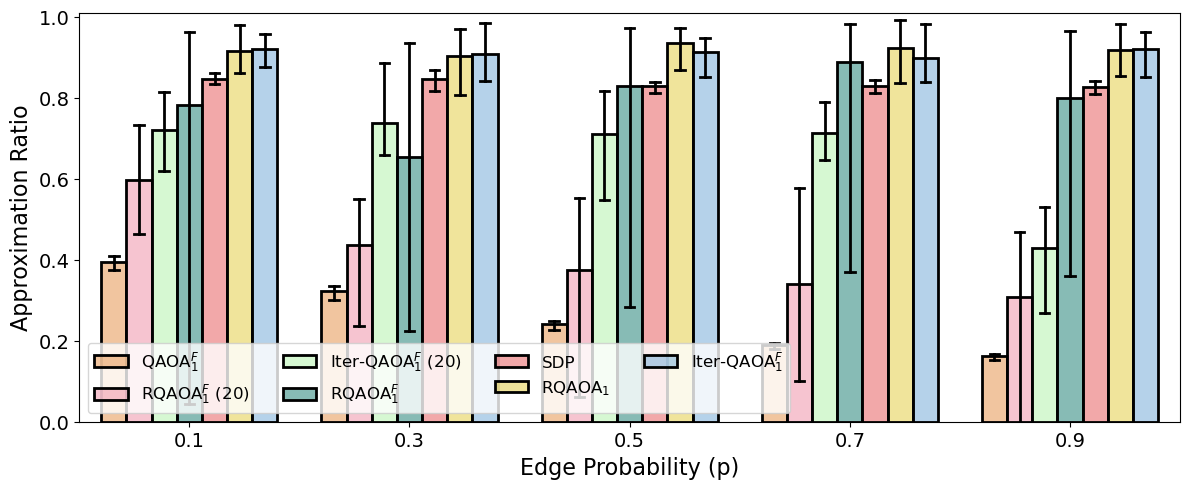

In [31]:
# Define custom color palette
palette = ['#FF9D48', '#ff8fab', '#B2FFA9', '#2a9d8f','#ff595e', '#fee440', '#77B6EA']
algorithm_order = [r'QAOA$_1^{F}$', r'RQAOA$_1^{F}$ (20)', r'Iter-QAOA$_1^{F}$ (20)', r'RQAOA$_1^{F}$', 'SDP', r'RQAOA$_1$', r'Iter-QAOA$_1^{F}$']

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 5))

# Create barplot
sns.barplot(
    data=df,
    x="p", y="Approximation Ratio", hue="Algorithm",
    errorbar=min_max_error, palette=palette, edgecolor='black', linewidth=2, hue_order=algorithm_order,
    capsize=0.3, err_kws={'linewidth': 2, 'color': 'black'}, width=0.8, ax=ax)

# Set transparency only for bar colors, not edgecolors
for bar in ax.patches:
    facecolor = bar.get_facecolor()
    bar.set_facecolor((*facecolor[:3], 0.6))  # Apply alpha only to facecolor

# Customize the plot
ax.set_ylabel('Approximation Ratio', fontsize=16)
ax.set_xlabel('Edge Probability (p)', fontsize=16)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', fontsize=12, ncol=4)
ax.set_ylim(0., 1.01)

# Set tick parameters
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
#plt.savefig('fields_comp_128.pdf', bbox_inches='tight')
plt.show()

In [21]:
size = 256
ps = [0.1, 0.3, 0.5, 0.7, 0.9]

qaoa_er_costs = {p:[] for p in ps}
rqaoa_er_costs = {p:[] for p in ps}
rqaoaf_er_costs = {p:[] for p in ps}
rqaoaf_def_er_costs = {p:[] for p in ps}
rqaoaf_20_er_costs = {p:[] for p in ps}
rqaoaf_def_20_er_costs = {p:[] for p in ps}
sdp_er_costs = {p:[] for p in ps}


for p in ps:
    for i in range(1, 21):
        filename = f"simulation_data/erf_{size}_{p}_{i}.json"
        bfilename = f"benchmark_data/erf_{size}_{p}_{i}.gz"
        _, gurobi_cost, _, _ = read_graph_from_file(bfilename)
        qaoa_cost, rqaoa_cost, rqaoaf_cost, rqaoaf_20_cost, rqaoaf_def_cost, rqaoaf_def_20_cost, sdp_cost = read_sim_results(filename)
        qaoa_er_costs[p].append(qaoa_cost/gurobi_cost)
        
        rqaoa_er_costs[p].append(rqaoa_cost/gurobi_cost)
        rqaoaf_er_costs[p].append(rqaoaf_cost/gurobi_cost)

        rqaoaf_20_er_costs[p].append(rqaoaf_20_cost/gurobi_cost)
        rqaoaf_def_er_costs[p].append(rqaoaf_def_cost/gurobi_cost)

        rqaoaf_def_20_er_costs[p].append(rqaoaf_def_20_cost/gurobi_cost)
        sdp_ar = [scost/gurobi_cost for scost in sdp_cost]
        sdp_er_costs[p].append(np.mean(sdp_ar))

In [22]:
data = []

for p in ps:   
    for cost in qaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'QAOA$_1^{F}$'})
    for cost in rqaoa_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1$'}) # Optimal RQAOA on Ising Model without External Fields
    for cost in rqaoaf_def_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1^{F}$'}) # Optimal RQAOA on Ising Model with External Fields
    for cost in rqaoaf_def_20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'RQAOA$_1^{F}$ (20)'})
    for cost in rqaoaf_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'Iter-QAOA$_1^{F}$'})
    for cost in rqaoaf_20_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': r'Iter-QAOA$_1^{F}$ (20)'})
    for cost in sdp_er_costs[p]:
        data.append({'p': p, 'Approximation Ratio': cost, 'Algorithm': 'SDP'})
    

# Convert to DataFrame for seaborn
df = pd.DataFrame(data)

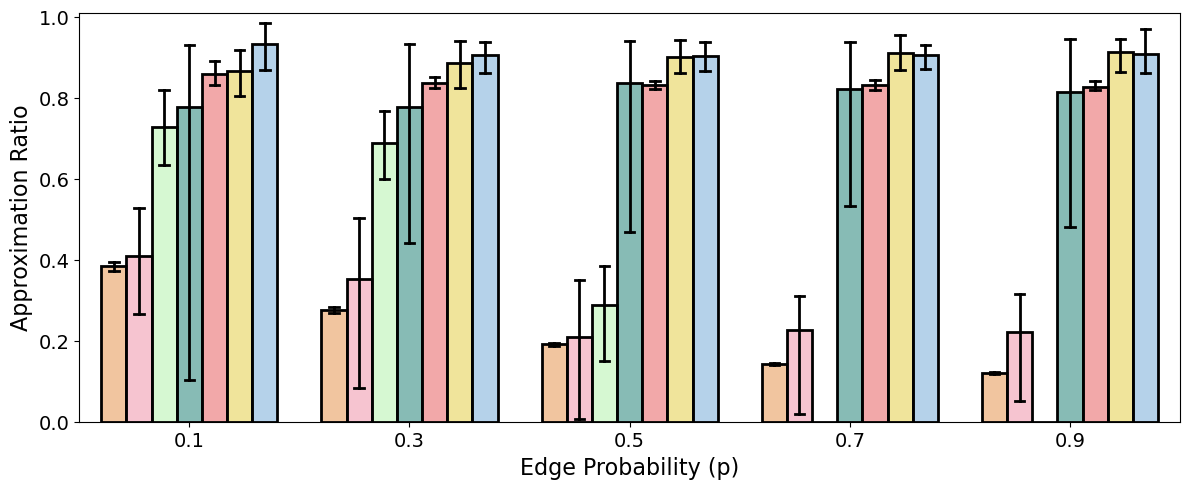

In [23]:
# Define custom color palette
palette = ['#FF9D48', '#ff8fab', '#B2FFA9', '#2a9d8f','#ff595e', '#fee440', '#77B6EA']
algorithm_order = [r'QAOA$_1^{F}$', r'RQAOA$_1^{F}$ (20)', r'Iter-QAOA$_1^{F}$ (20)', r'RQAOA$_1^{F}$', 'SDP', r'RQAOA$_1$', r'Iter-QAOA$_1^{F}$']

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 5))

# Create barplot
sns.barplot(
    data=df,
    x="p", y="Approximation Ratio", hue="Algorithm",
    errorbar=min_max_error, palette=palette, edgecolor='black', linewidth=2, hue_order=algorithm_order,
    capsize=0.3, err_kws={'linewidth': 2, 'color': 'black'}, width=0.8, ax=ax, legend=False
)

# Set transparency only for bar colors, not edgecolors
for bar in ax.patches:
    facecolor = bar.get_facecolor()
    bar.set_facecolor((*facecolor[:3], 0.6))  # Apply alpha only to facecolor

# Customize the plot
ax.set_ylabel('Approximation Ratio', fontsize=16)
ax.set_xlabel('Edge Probability (p)', fontsize=16)
#ax.legend(loc='lower left', fontsize=15, ncol=3)
ax.set_ylim(0., 1.01)

# Set tick parameters
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
#plt.savefig('fields_comp_256.pdf', bbox_inches='tight')
plt.show()